In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
# import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/useful/gaia_edr3_g_18_dr9.fits', rows=[0]))

SOURCE_ID,RA,DEC,PHOT_G_MEAN_MAG,PHOT_G_MEAN_FLUX_OVER_ERROR,PHOT_BP_MEAN_MAG,PHOT_RP_MEAN_MAG,ASTROMETRIC_EXCESS_NOISE
int64,float64,float64,float32,float32,float32,float32,float32
4295806720,44.99615537864534,0.005615226341865997,17.641426,796.5234,18.080235,17.061232,0.3806193


In [9]:
columns = ['RA', 'DEC', 'PHOT_G_MEAN_MAG', 'ASTROMETRIC_EXCESS_NOISE', 'PHOT_G_MEAN_FLUX_OVER_ERROR']
gaia = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/useful/gaia_edr3_g_18_dr9.fits', columns=columns))
mask = gaia['PHOT_G_MEAN_FLUX_OVER_ERROR']>0
gaia = gaia[mask]
print(len(gaia))

41052993


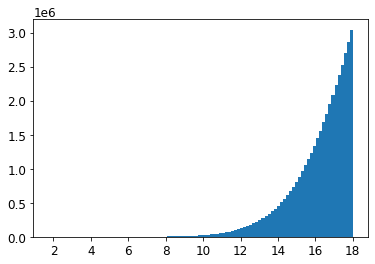

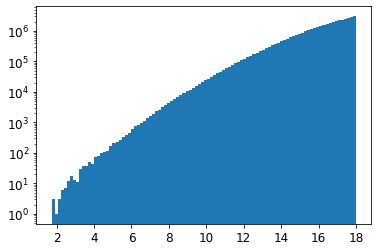

In [11]:
plt.hist(gaia['PHOT_G_MEAN_MAG'], 100)
plt.show()

plt.hist(gaia['PHOT_G_MEAN_MAG'], 100, log=True)
plt.show()

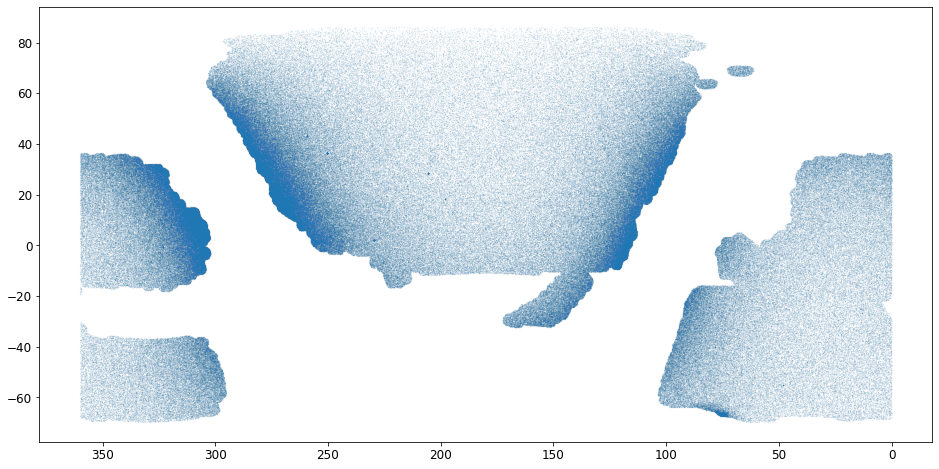

In [12]:
idx = np.random.choice(len(gaia), size=len(gaia)//50)
plt.figure(figsize=(16, 8))
plt.plot(gaia['RA'][idx], gaia['DEC'][idx], '.', ms=0.1, alpha=0.5)
plt.gca().invert_xaxis()
plt.show()

In [15]:
target_class = 'lrg'
cat_south = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/targets/dr9.0/1.0.0/resolve/dr9_{}_south_1.0.0_basic.fits'.format(target_class), columns=['RA', 'DEC']))
cat_north = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/targets/dr9.0/1.0.0/resolve/dr9_{}_north_1.0.0_basic.fits'.format(target_class), columns=['RA', 'DEC']))
cat = vstack([cat_south, cat_north])
print(len(cat))

12338990


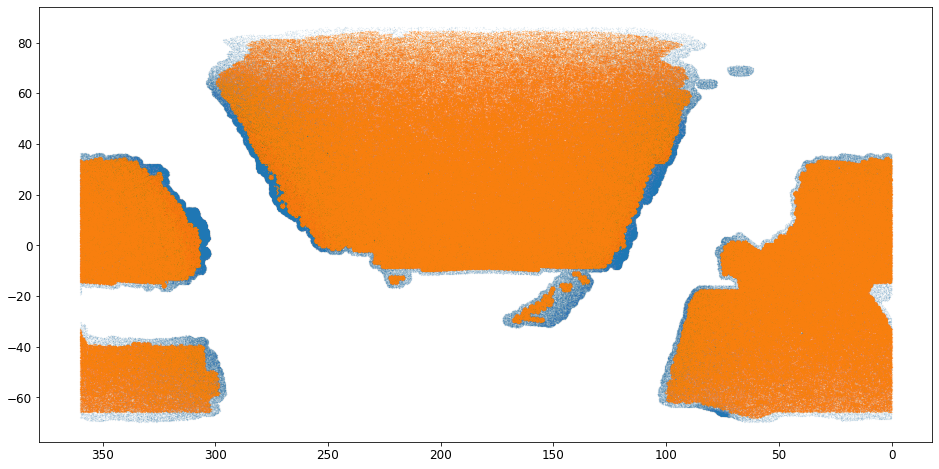

In [16]:
plt.figure(figsize=(16, 8))

idx = np.random.choice(len(gaia), size=len(gaia)//50)
plt.plot(gaia['RA'][idx], gaia['DEC'][idx], '.', ms=0.1, alpha=0.5)

idx = np.random.choice(len(cat), size=len(cat)//5)
plt.plot(cat['RA'][idx], cat['DEC'][idx], '.', ms=0.1, alpha=1)

plt.gca().invert_xaxis()
plt.show()

-------

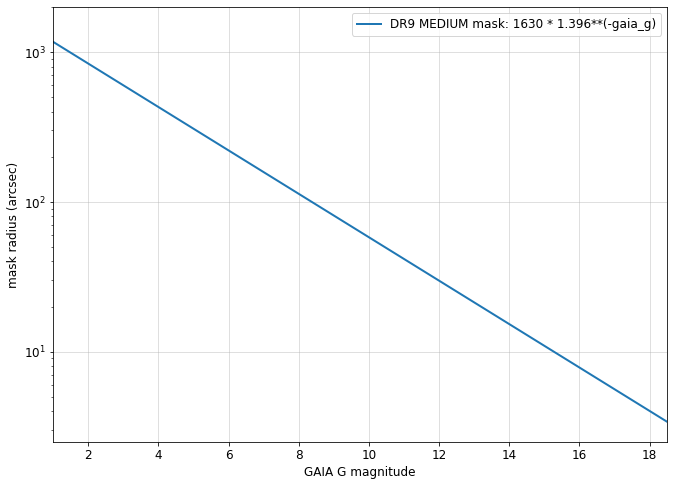

In [18]:
mag = np.linspace(0, 20, 1000)
radius = 1630 * 1.396**(-mag)

plt.figure(figsize=(11, 8))
plt.semilogy(mag, radius, '-', lw=2, label='DR9 MEDIUM mask: 1630 * 1.396**(-gaia_g)')
plt.grid(alpha=0.5)
plt.xlabel('GAIA G magnitude')
plt.ylabel('mask radius (arcsec)')
# plt.axhline(1800*0.262, lw=1, ls='--', color='k', label='maximum radius')
plt.axis([1., 18.5, 2.5, 2000])
plt.legend()
plt.show()

In [19]:
gaia['radius'] = 1630 * 1.396**(-gaia['PHOT_G_MEAN_MAG'])

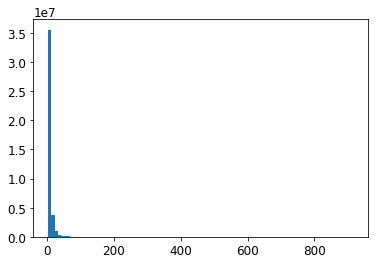

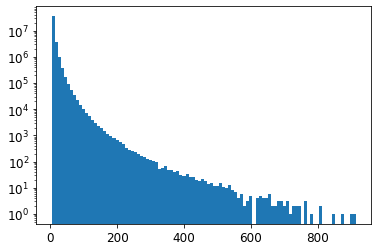

In [20]:
plt.hist(gaia['radius'], 100)
plt.show()

plt.hist(gaia['radius'], 100, log=True)
plt.show()

In [32]:
# Raw masked area to G<16
np.sum(np.pi * gaia['radius'][mask_160]**2) / 3600**2

1286.62107654321

In [34]:
# Raw masked area to G<18
np.sum(np.pi * gaia['radius']**2) / 3600**2

1486.4747456790124

In [25]:
mask_160 = gaia['PHOT_G_MEAN_MAG']<16

gaia_max_list = np.arange(8, 18.5, 0.5)
area_frac = np.zeros(len(gaia_max_list))
for index, gaia_max in enumerate(gaia_max_list):
    mask = gaia['PHOT_G_MEAN_MAG']<gaia_max
    area_frac[index] = np.sum(gaia['radius'][mask]**2)/np.sum(gaia['radius'][mask_160]**2)

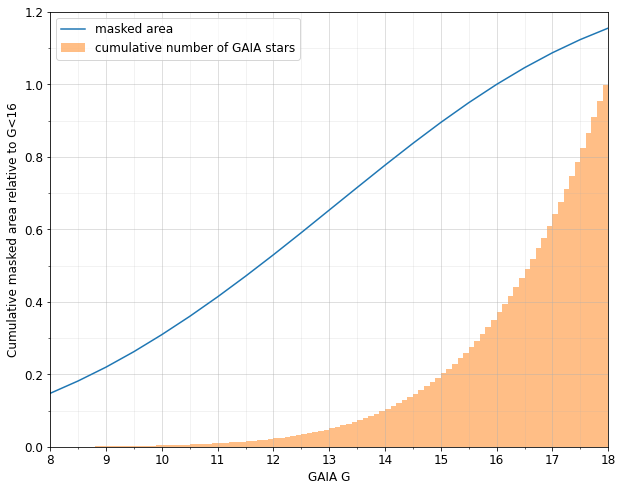

In [29]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(gaia_max_list, area_frac, label='masked area')
# mask_radius_new_plot = 1630 * 1.396**(-gaia_max_list)
# ax.plot(gaia_max_list, mask_radius_new_plot/60, '--', label='mask radius')
# ax.plot(gaia_max_list, area_frac_old)
ax.set_xlabel('GAIA G')
ax.set_ylabel('Cumulative masked area relative to G<16')
ax.hist(gaia['PHOT_G_MEAN_MAG'], cumulative=True, range=(8, 18), bins=100, alpha=0.5, label='cumulative number of GAIA stars',
        weights=np.ones(len(gaia['PHOT_G_MEAN_MAG']))/len(gaia['PHOT_G_MEAN_MAG'])*1.)
ax.legend()

x_major_ticks = np.arange(0, 21, 1)
x_minor_ticks = np.arange(0, 21, 0.5)
y_major_ticks = np.arange(0, 2.1, 0.2)
y_minor_ticks = np.arange(0, 2.1, 0.1)

ax.set_xticks(x_major_ticks)
ax.set_xticks(x_minor_ticks, minor=True)
ax.set_yticks(y_major_ticks)
ax.set_yticks(y_minor_ticks, minor=True)

# And a corresponding grid
ax.grid(which='both')

# Or if you want different settings for the grids:
ax.grid(which='minor', alpha=0.2)
ax.grid(which='major', alpha=0.5)

ax.axis([8, 18, 0, 1.2])

plt.show()